# SPO Baseline — True SPO Regret（对应原始 e2e_v4_mu_std_diag_with_zeta_10）

本文件一一对应原始 v4 notebook：保留 LP/top-quantile oracle、`ZETA_TRAIN/ZETA_TEST`、MLP、rolling window 与评价口径，只把训练主损失替换为 true SPO-style decision regret。


## 1. 配置

In [1]:
from pathlib import Path

# ── 相对路径：默认 notebook 与数据文件在同一目录 ───────────────────────────
# 如果你把数据放在 ./data/ 下，只需要改成 DATA_DIR = PROJECT_ROOT / "data"
PROJECT_ROOT = Path.cwd()
DATA_DIR     = PROJECT_ROOT
OUT_DIR      = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH   = DATA_DIR / 'hs300_factor_data_filled.parquet'
PANEL_PATH = DATA_DIR / 'factor_panel_v2_processed.parquet'
IC_PATH    = DATA_DIR / '03v3_ic_summary.csv'

# ── 因子筛选 ─────────────────────────────────────────────────────────────
IC_TSTAT_THRESHOLD = 2.0
MIN_COVERAGE       = 0.70
FWD_RET_COVERAGE   = 0.80

# ── 模型与训练参数（保持原文件口径）───────────────────────────────────────
HIDDEN_DIM = 32
SEED       = 42
N_WARM     = 10
N_E2E      = 60
LR_MSE     = 1e-3
LR_E2E     = 1e-4
GRAD_CLIP  = 1.0
BATCH_SIZE = 8

# ── LP / top-quantile 平滑参数（保持 v4 口径）───────────────────────────────
ZETA_TRAIN = 10.0
ZETA_TEST  = 0.001
ALPHA_IC   = 0.05
MAX_W_FRAC = 10
TC_RATE    = 0.003
TRAIN_WINDOW = 36
STEP_SIZE    = 3

# ── SPO baseline 开关 ─────────────────────────────────────────────────────
SPO_RUN_NAME   = 'spo_true_regret_v4_mu_std_diag_zeta10'
SPO_LOSS_LABEL = 'True SPO regret / decision regret'

print("=" * 72)
print(f"{SPO_RUN_NAME}")
print("=" * 72)
print(f"DATA_DIR     = {DATA_DIR}")
print(f"PANEL_PATH   = {PANEL_PATH}")
print(f"IC_PATH      = {IC_PATH}")
print(f"OUT_DIR      = {OUT_DIR}")
print(f"LOSS         = {SPO_LOSS_LABEL}")
print(f"N_WARM={N_WARM}, N_E2E={N_E2E}, BATCH_SIZE={BATCH_SIZE}")


spo_true_regret_v4_mu_std_diag_zeta10
DATA_DIR     = /root
PANEL_PATH   = /root/factor_panel_v2_processed.parquet
IC_PATH      = /root/03v3_ic_summary.csv
OUT_DIR      = /root/outputs
LOSS         = True SPO regret / decision regret
N_WARM=10, N_E2E=60, BATCH_SIZE=8


## 2. 导入与数据加载

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from collections import Counter
from scipy.optimize import brentq
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F

torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['font.sans-serif'] = ['SimHei','Arial Unicode MS','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def date_as_date(x):
    return pd.Timestamp(x).date()

def date_as_ym(x):
    return pd.Timestamp(x).strftime('%y-%m')

def date_as_Ym(x):
    return pd.Timestamp(x).strftime('%Y-%m')

panel = pd.read_parquet(PANEL_PATH)
panel['date'] = pd.to_datetime(panel['date'])
ic_df = pd.read_csv(IC_PATH, index_col=0)

if 'Sig(|t|>2)' in ic_df.columns:
    sig_mask = ic_df['Sig(|t|>2)']
elif 't_stat' in ic_df.columns:
    sig_mask = ic_df['t_stat'].abs() > IC_TSTAT_THRESHOLD
else:
    raise ValueError("IC 文件需含 t_stat 或 Sig(|t|>2) 列")

SIG_FACTORS = list(ic_df[sig_mask].index)
N_FEATURES  = len(SIG_FACTORS)
print(f"Factor panel: {panel.shape}  ({panel['date'].nunique()} months)")
print(f"显著因子 ({N_FEATURES} 个): {SIG_FACTORS}")
assert N_FEATURES >= 2

Factor panel: (21760, 105)  (68 months)
显著因子 (10 个): ['F91_ocf_ni', 'F97_accruals', 'F80_ocf_mv', 'F74_cfp', 'F55_holding_adj', 'F81_size', 'F34_vol_of_vol', 'F88_cash_roe', 'F41_turn_std', 'F30_range_vol']


## 3. 股票池 & 特征

In [3]:
all_dates = sorted(panel['date'].unique())

def get_valid_stocks(df, factors):
    return set(df.dropna(subset=factors + ['fwd_ret'])['ts_code'].unique())

month_valid = {d: get_valid_stocks(panel[panel['date']==d], SIG_FACTORS)
               for d in all_dates}
stock_cnt = Counter(s for v in month_valid.values() for s in v)
universe  = sorted(s for s,c in stock_cnt.items() if c/len(all_dates) >= MIN_COVERAGE)
N         = len(universe)
MAX_W     = MAX_W_FRAC / N

panel_u = (panel[panel['ts_code'].isin(universe)]
           .sort_values(['date','ts_code']).reset_index(drop=True))
for col in SIG_FACTORS:
    panel_u[col] = panel_u.groupby('date')[col].transform(
        lambda x: x.fillna(0 if x.isna().all() else x.mean()))
panel_u['fwd_ret'] = panel_u.groupby('date')['fwd_ret'].transform(
    lambda x: x.fillna(x.median() if not x.isna().all() else 0))

def cross_sec_zscore(arr):
    mu  = arr.mean(axis=0, keepdims=True)
    sig = np.maximum(arr.std(axis=0, keepdims=True), 1e-8)
    return np.nan_to_num((arr-mu)/sig).astype('float32')

fwd_cov     = panel_u.groupby('date')['fwd_ret'].apply(lambda x: x.notna().mean())
dates_valid = [d for d in sorted(panel_u['date'].unique())
               if fwd_cov.get(d, 0) >= FWD_RET_COVERAGE]

X_tensors, y_tensors = [], []
for d in dates_valid:
    sub = panel_u[panel_u['date']==d].sort_values('ts_code')
    X_tensors.append(torch.tensor(cross_sec_zscore(sub[SIG_FACTORS].values)))
    y_tensors.append(torch.tensor(sub['fwd_ret'].values.astype('float32')))

T = len(X_tensors)
print(f"股票池: {N} 只   max_w = {MAX_W_FRAC}/N = {MAX_W:.4f} ({MAX_W*100:.2f}%)")
print(f"有效月份: {T}  ({pd.Timestamp(dates_valid[0]).date()} ~ {pd.Timestamp(dates_valid[-1]).date()})")

# 预先验证 ZETA_TRAIN 的 free variable 数量
_mu_test = np.random.randn(N).astype(np.float64)
def _quick_lp(mu_np, max_w, zeta):
    def g(nu): return np.clip((mu_np-nu)/zeta, 0, max_w).sum()-1.0
    try:
        nu = brentq(g, mu_np.min()-max_w*zeta-1, mu_np.max()+1, xtol=1e-10, maxiter=200)
        w = np.clip((mu_np-nu)/zeta, 0, max_w); return w/w.sum()
    except: return np.ones(len(mu_np))/len(mu_np)
_w50   = _quick_lp(_mu_test, MAX_W, ZETA_TRAIN)
_w0001 = _quick_lp(_mu_test, MAX_W, ZETA_TEST)
_eps = 1e-6
print(f"\n预期 free variable 数量（随机 μ 验证）:")
print(f"  ZETA_TRAIN={ZETA_TRAIN}: {int(((_w50>_eps)&(_w50<MAX_W-_eps)).sum())} free / {N}  ← 训练用")
print(f"  ZETA_TEST ={ZETA_TEST}: {int(((_w0001>_eps)&(_w0001<MAX_W-_eps)).sum())} free / {N}  ← 测试用（论文原意）")

股票池: 252 只   max_w = 10/N = 0.0397 (3.97%)
有效月份: 68  (2020-04-30 ~ 2025-11-28)

预期 free variable 数量（随机 μ 验证）:
  ZETA_TRAIN=10.0: 14 free / 252  ← 训练用
  ZETA_TEST =0.001: 1 free / 252  ← 测试用（论文原意）


## 4. 滚动窗口

In [4]:
rolling_windows = []
start = 0
while start + TRAIN_WINDOW + STEP_SIZE <= T:
    rolling_windows.append({
        'train_start': start,           'train_end': start + TRAIN_WINDOW,
        'test_start' : start + TRAIN_WINDOW,
        'test_end'   : min(start + TRAIN_WINDOW + STEP_SIZE, T),
    })
    start += STEP_SIZE

assert rolling_windows, f"数据不足，T={T}，需至少 {TRAIN_WINDOW + STEP_SIZE} 月"
fw, lw = rolling_windows[0], rolling_windows[-1]
n_test_total = sum(w['test_end'] - w['test_start'] for w in rolling_windows)

print(f"滚动窗口: {len(rolling_windows)} 个  累计测试月: {n_test_total}")
print(f"首: [{pd.Timestamp(dates_valid[fw['train_start']]).date()}~{pd.Timestamp(dates_valid[fw['train_end']-1]).date()}] → [{pd.Timestamp(dates_valid[fw['test_start']]).date()}~{pd.Timestamp(dates_valid[fw['test_end']-1]).date()}]")
print(f"末: 测试 [{pd.Timestamp(dates_valid[lw['test_start']]).date()}~{pd.Timestamp(dates_valid[lw['test_end']-1]).date()}]")


滚动窗口: 10 个  累计测试月: 30
首: [2020-04-30~2023-03-31] → [2023-04-28~2023-06-30]
末: 测试 [2025-07-31~2025-09-30]


## 5. 可微 LP 层（论文 Section 3.4 / Eq.15 / Eq.18）

**关键改动**：用 `brentq` 二分法替换 `scipy.minimize`，速度快 ~1500x，且支持不同 `zeta` 的 train/test 层分离。

In [5]:
# ── 快速闭式 LP 求解器 ───────────────────────────────────────────────────
def solve_smooth_lp(mu_np: np.ndarray, max_w: float, zeta: float) -> np.ndarray:
    """
    闭式解：w_i* = clip((μ_i − ν*)/ζ, 0, max_w)
    ν* 由预算约束 Σw_i=1 确定（二分法）。
    
    O(N·log(1/ε)) vs scipy SLSQP 的 O(N³)，实测快 ~1500x。
    """
    n = len(mu_np)
    def budget(nu):
        return np.clip((mu_np - nu) / zeta, 0.0, max_w).sum() - 1.0

    nu_lo = mu_np.min() - max_w * zeta - 1.0   # budget >> 1
    nu_hi = mu_np.max() + 1.0                   # budget << 0
    try:
        nu_star = brentq(budget, nu_lo, nu_hi, xtol=1e-10, maxiter=300)
        w = np.clip((mu_np - nu_star) / zeta, 0.0, max_w)
        s = w.sum()
        return w / s if s > 1e-10 else np.ones(n) / n
    except Exception:
        return np.ones(n) / n


# ── KKT 反传（论文 Eq.12-13）────────────────────────────────────────────
class LPSmoothFunction(torch.autograd.Function):
    """
    Forward : 快速 LP 求解（brentq 闭式）
    Backward: KKT 隐函数定理，仅 free variable 有非零梯度
              KKT 矩阵（无 Σ！纯 LP）:
                K = [[ζ·I_F,  e_F],
                     [e_F^T,   0 ]]
              dw_F/dμ_F = K^{-1}[:n_F, :n_F]
    """

    @staticmethod
    def forward(ctx, mu, max_w, zeta):
        n = mu.shape[0]
        mu_np = mu.detach().numpy().astype(np.float64)
        w_np  = solve_smooth_lp(mu_np, max_w, zeta)
        eps   = 1e-6
        free  = (w_np > eps) & (w_np < max_w - eps)

        ctx.save_for_backward(torch.tensor(w_np, dtype=mu.dtype))
        ctx.free = free; ctx.zeta = zeta; ctx.n = n
        return torch.tensor(w_np, dtype=mu.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        free, zeta, n = ctx.free, ctx.zeta, ctx.n
        n_free = int(free.sum())

        if n_free == 0:
            return torch.zeros(n, dtype=torch.float32), None, None

        free_idx = np.where(free)[0]
        K = np.zeros((n_free+1, n_free+1))
        K[:n_free, :n_free] = zeta * np.eye(n_free)
        K[:n_free,  n_free] = 1.0
        K[ n_free, :n_free] = 1.0

        try:
            K_inv = np.linalg.solve(K, np.eye(n_free+1))
        except np.linalg.LinAlgError:
            K_inv = np.linalg.lstsq(K, np.eye(n_free+1), rcond=None)[0]

        dw_dmu  = K_inv[:n_free, :n_free]
        grad_np = grad_output.numpy().astype(np.float64)
        grad_mu = np.zeros(n)
        grad_mu[free_idx] = dw_dmu @ grad_np[free_idx]
        return torch.tensor(grad_mu, dtype=torch.float32), None, None


class DifferentiableLP(nn.Module):
    def __init__(self, max_w, zeta):
        super().__init__()
        self.max_w = max_w; self.zeta = zeta

    def forward(self, mu):
        return LPSmoothFunction.apply(mu, self.max_w, self.zeta)


# ── 创建两个 LP 层：训练用（大ζ）和测试用（小ζ）──────────────────────────
lp_train = DifferentiableLP(max_w=MAX_W, zeta=ZETA_TRAIN)
lp_test  = DifferentiableLP(max_w=MAX_W, zeta=ZETA_TEST)

print(f"lp_train: max_w={MAX_W:.4f}, ζ={ZETA_TRAIN}  ← 训练时使用（大ζ，梯度丰富）")
print(f"lp_test : max_w={MAX_W:.4f}, ζ={ZETA_TEST} ← 测试时使用（小ζ，严格 top-10%）")

# ── 梯度流验证 ───────────────────────────────────────────────────────────
print("\n=== 梯度流验证 ===")
torch.manual_seed(0)
_mlp = nn.Sequential(nn.Linear(N_FEATURES, 32), nn.ReLU(), nn.Linear(32, 1))
_X, _y = X_tensors[min(10,T-1)], y_tensors[min(10,T-1)]

for layer, label in [(lp_train, "lp_train (ZETA_TRAIN=50)"),
                     (lp_test,  "lp_test  (ZETA_TEST=0.001)")]:
    _mu = _mlp(_X).squeeze(-1)
    _w  = layer(_mu)
    loss = -(_w * _y).sum()
    loss.backward()
    norms  = [p.grad.norm().item() if p.grad is not None else 0 for p in _mlp.parameters()]
    _free  = int(((_w.detach()>1e-6) & (_w.detach()<MAX_W-1e-6)).sum())
    _nz    = int((_w.detach()>0.001).sum())
    print(f"\n  {label}")
    print(f"    free_vars={_free}/{N}  nonzero={_nz}  sum={_w.sum():.6f}")
    print(f"    grad_norms: {[f'{v:.2e}' for v in norms]}")
    print(f"    {'✓ 梯度正常' if all(v>0 for v in norms) else '⚠ 部分梯度为零（free=0 时正常）'}")
    for p in _mlp.parameters():
        if p.grad is not None: p.grad.zero_()
del _mlp, _X, _y, _mu, _w, loss

lp_train: max_w=0.0397, ζ=10.0  ← 训练时使用（大ζ，梯度丰富）
lp_test : max_w=0.0397, ζ=0.001 ← 测试时使用（小ζ，严格 top-10%）

=== 梯度流验证 ===

  lp_train (ZETA_TRAIN=50)
    free_vars=118/252  nonzero=101  sum=1.000000
    grad_norms: ['4.03e-01', '8.07e-02', '5.17e-01', '0.00e+00']
    ⚠ 部分梯度为零（free=0 时正常）

  lp_test  (ZETA_TEST=0.001)
    free_vars=1/252  nonzero=26  sum=1.000000
    grad_norms: ['0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00']
    ⚠ 部分梯度为零（free=0 时正常）


## 6. 模型定义

In [6]:
class CrossSectionalMLP(nn.Module):
    """截面参数共享 MLP: (N,F) → (N,)  双隐藏层 + BN + Dropout"""
    def __init__(self, n_features=N_FEATURES, hidden=HIDDEN_DIM):
        super().__init__()
        h2 = max(hidden//2, 4)
        self.net = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Linear(n_features, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(hidden, h2),         nn.BatchNorm1d(h2),     nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(h2, 1)
        )
    def forward(self, X): return self.net(X).squeeze(-1)

_tmp = CrossSectionalMLP()
print(f"模型: {N_FEATURES}→{HIDDEN_DIM}→{HIDDEN_DIM//2}→1   参数 {sum(p.numel() for p in _tmp.parameters())}个")
del _tmp

模型: 10→32→16→1   参数 1013个


## 7. 训练函数（SPO baseline：True SPO regret / decision regret）


In [7]:
def ic_aux_loss(mu_hat, y_true, alpha=ALPHA_IC):
    """Same IC auxiliary channel as v4; set ALPHA_IC=0 for pure SPO loss."""
    if alpha <= 0:
        return torch.tensor(0.0, dtype=mu_hat.dtype)
    mu_c = mu_hat - mu_hat.mean()
    y_c  = (y_true - y_true.mean()).detach()
    ic_t = (mu_c * y_c).sum() / (mu_c.norm() * y_c.norm() + 1e-8)
    return -alpha * ic_t


def safe_lp(layer, mu):
    """Robust LP oracle wrapper. Fallback keeps a zero-gradient graph."""
    try:
        return layer(mu)
    except Exception:
        return torch.ones_like(mu) / mu.numel() + 0.0 * mu


def portfolio_cost_lp_from_return(r_vec, w):
    """Cost form for v4 LP: phi(r,w) = - r^T w. Lower is better."""
    return -(w * r_vec).sum()


def build_true_oracle_cache_lp(y_tr, layer):
    """w_true_t = w*(r_t). It is theta-free, so cache and detach."""
    cache = []
    with torch.no_grad():
        for y in y_tr:
            try:
                cache.append(layer(y.detach()).detach())
            except Exception:
                cache.append((torch.ones_like(y) / y.numel()).detach())
    return cache


def spo_true_regret_loss_t(mu_hat, y_true, w_true):
    """True SPO-style regret under the same v4 LP oracle."""
    w_pred = safe_lp(lp_train, mu_hat)
    cost_pred = portfolio_cost_lp_from_return(y_true, w_pred)
    cost_true = portfolio_cost_lp_from_return(y_true, w_true).detach()
    return cost_pred - cost_true, w_pred


def train_spo_v4(model, X_tr, y_tr, n_warm, n_spo, lr_mse, lr_spo,
                 grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE, verbose=False):
    T_tr = len(X_tr)
    hist = {'mse': [], 'spo': [], 'free_vars': [], 'mu_std_mse': [], 'mu_std_spo': []}

    # Phase 1: MSE warm start, unchanged architecture and optimizer family.
    opt = optim.Adam(model.parameters(), lr=lr_mse)
    for ep in range(n_warm):
        model.train(); ep_loss = 0.0; n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1
        hist['mse'].append(ep_loss / max(n_batches, 1))
        with torch.no_grad():
            hist['mu_std_mse'].append(float(np.mean([model(X_tr[t]).std().item() for t in range(T_tr)])))

    true_cache = build_true_oracle_cache_lp(y_tr, lp_train)

    # Phase 2: true SPO regret, same LP oracle as v4.
    opt = optim.Adam(model.parameters(), lr=lr_spo)
    for ep in range(n_spo):
        model.train(); ep_loss = 0.0; n_batches = 0; ep_free = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = torch.tensor(0.0)
            for t in range(bs, be):
                mu_hat = model(X_tr[t])
                loss_t, w_diag = spo_true_regret_loss_t(mu_hat, y_tr[t], true_cache[t])
                bl = bl + loss_t + ic_aux_loss(mu_hat, y_tr[t])
                with torch.no_grad():
                    _w = w_diag.detach()
                    ep_free += int(((_w > 1e-6) & (_w < MAX_W - 1e-6)).sum())

            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1

        avg_loss = ep_loss / max(n_batches, 1)
        avg_free = ep_free / max(T_tr, 1)
        hist['spo'].append(avg_loss)
        hist['free_vars'].append(avg_free)
        with torch.no_grad():
            hist['mu_std_spo'].append(float(np.mean([model(X_tr[t]).std().item() for t in range(T_tr)])))
        if verbose and (ep % 10 == 0 or ep == n_spo - 1):
            print(f"    SPO ep{ep:02d}: loss={avg_loss:+.4f}  avg_free={avg_free:.1f}/{N}")
    return hist


def train_mse(model, X_tr, y_tr, n_epochs, lr,
              grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    T_tr = len(X_tr); hist = []
    opt = optim.Adam(model.parameters(), lr=lr)
    for ep in range(n_epochs):
        model.train(); ep_loss = 0.0; n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1
        hist.append(ep_loss / max(n_batches, 1))
    return hist

print("训练函数定义完毕")
print(f"  SPO: {SPO_LOSS_LABEL}  (v4 LP, lp_train ζ={ZETA_TRAIN})")
print(f"  MSE: 纯 MSE {N_WARM + N_E2E} epochs")


训练函数定义完毕
  SPO: True SPO regret / decision regret  (v4 LP, lp_train ζ=10.0)
  MSE: 纯 MSE 70 epochs


## 8. 滚动运行器（SPO baseline）


In [8]:
def run_rolling(mode: str):
    assert mode in ('spo', 'mse')
    res = {'returns': [], 'weights': [], 'dates': [], 'bench': [],
           'free_vars': [], 'loss_curves': [], 'train_free': []}
    w_prev = np.ones(N) / N
    t0 = time.time()

    for idx, win in enumerate(rolling_windows):
        ts, te = win['train_start'], win['train_end']
        vs, ve = win['test_start'],  win['test_end']
        X_tr = [X_tensors[i] for i in range(ts, te)]
        y_tr = [y_tensors[i] for i in range(ts, te)]

        torch.manual_seed(SEED + idx * 37)
        model_w = CrossSectionalMLP()

        if mode == 'spo':
            hist = train_spo_v4(model_w, X_tr, y_tr, N_WARM, N_E2E, LR_MSE, LR_E2E)
            final_loss = hist['spo'][-1] if hist['spo'] else float('nan')
            avg_train_free = hist['free_vars'][-1] if hist['free_vars'] else 0.0
            res['loss_curves'].append(hist['spo'])
        else:
            hist = train_mse(model_w, X_tr, y_tr, N_WARM + N_E2E, LR_MSE)
            final_loss = hist[-1] if hist else float('nan')
            avg_train_free = 0.0
            res['loss_curves'].append(hist)

        model_w.eval(); n_free_sum = 0
        for i in range(vs, ve):
            with torch.no_grad():
                mu_hat = model_w(X_tensors[i])
                try:
                    w = lp_test(mu_hat).detach().cpu().numpy()
                except Exception:
                    w = np.ones(N) / N

            n_free = int(((w > 1e-6) & (w < MAX_W - 1e-6)).sum())
            n_free_sum += n_free
            gross_ret = float((w * y_tensors[i].numpy()).sum())
            tc_cost = TC_RATE * np.abs(w - w_prev).sum()
            res['returns'].append(gross_ret - tc_cost)
            res['weights'].append(w)
            res['dates'].append(dates_valid[i])
            res['bench'].append(y_tensors[i].mean().item())
            res['free_vars'].append(n_free)
            w_prev = w

        avg_test_free = n_free_sum / max(ve - vs, 1)
        print(f"  [{mode.upper()}] win{idx+1:02d}/{len(rolling_windows)}"
              f"  [{pd.Timestamp(dates_valid[ts]).strftime('%y-%m')}~{pd.Timestamp(dates_valid[te-1]).strftime('%y-%m')}]"
              f"  → [{pd.Timestamp(dates_valid[vs]).strftime('%y-%m')}~{pd.Timestamp(dates_valid[ve-1]).strftime('%y-%m')}]"
              f"  loss={final_loss:+.4f}"
              f"  train_free={avg_train_free:.1f}  test_free={avg_test_free:.1f}"
              f"  {(time.time() - t0) / 60:.1f}min")
        res['train_free'].append(avg_train_free)

    return res

print("滚动运行器定义完毕")
print(f"  SPO 文件对应原始 v4: LP/top-quantile oracle, ZETA_TRAIN={ZETA_TRAIN}, ZETA_TEST={ZETA_TEST}")


滚动运行器定义完毕
  SPO 文件对应原始 v4: LP/top-quantile oracle, ZETA_TRAIN=10.0, ZETA_TEST=0.001


## 9. 执行实验


In [9]:
print("=" * 72)
print(f"SPO baseline from original v4: {SPO_LOSS_LABEL}")
print("=" * 72)
res_spo = run_rolling('spo')

print()
print("=" * 72)
print("MSE baseline from original v4: same window + same LP oracle")
print("=" * 72)
res_mse = run_rolling('mse')


SPO baseline from original v4: True SPO regret / decision regret


  [SPO] win01/10  [20-04~23-03]  → [23-04~23-06]  loss=+0.1614  train_free=64.4  test_free=1.0  0.3min


  [SPO] win02/10  [20-07~23-06]  → [23-07~23-09]  loss=+0.1504  train_free=71.4  test_free=1.0  0.6min


  [SPO] win03/10  [20-10~23-09]  → [23-10~23-12]  loss=+0.1458  train_free=74.3  test_free=1.0  0.9min


  [SPO] win04/10  [21-01~23-12]  → [24-01~24-03]  loss=+0.1377  train_free=68.6  test_free=1.0  1.2min


...

  [MSE] win06/10  [21-07~24-06]  → [24-07~24-09]  loss=+0.0175  train_free=0.0  test_free=1.0  0.3min


  [MSE] win07/10  [21-10~24-09]  → [24-10~24-12]  loss=+0.0165  train_free=0.0  test_free=1.3  0.4min


  [MSE] win08/10  [22-01~24-12]  → [25-01~25-03]  loss=+0.0141  train_free=0.0  test_free=1.7  0.5min


  [MSE] win09/10  [22-04~25-03]  → [25-04~25-06]  loss=+0.0138  train_free=0.0  test_free=1.0  0.5min


  [MSE] win10/10  [22-07~25-06]  → [25-07~25-09]  loss=+0.0159  train_free=0.0  test_free=1.0  0.6min


## 10. 业绩汇总（含换手率）


In [10]:
def calc_turnover(weights_list):
    to = []
    w_prev = np.ones(N) / N
    for w in weights_list:
        to.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(to)


def metrics(returns, weights_list, label='', verbose=True):
    r = np.array(returns)
    ann_ret = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else 0.0
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cum = np.cumprod(1 + r)
    dd = (cum / np.maximum.accumulate(cum)) - 1 if len(cum) else np.array([0.0])
    neg = r[r < 0]
    sortino = ann_ret / (neg.std(ddof=1) * np.sqrt(12)) if len(neg) > 1 and neg.std(ddof=1) > 0 else float('nan')
    win = (r > 0).mean() if len(r) else float('nan')
    to = calc_turnover(weights_list) if weights_list is not None else np.array([0.0])
    avg_to = to.mean()
    if verbose:
        print(f"{label:<34} AnnRet={ann_ret:+.2%}  AnnVol={ann_vol:.2%}  "
              f"SR={sharpe:.3f}  Sortino={sortino:.3f}  MDD={dd.min():.2%}  "
              f"Win={win:.1%}  AvgTO={avg_to:.2%}")
    return dict(Ann_Ret=ann_ret, Ann_Vol=ann_vol, Sharpe=sharpe,
                Sortino=sortino, MDD=dd.min(), Win=win, AvgTO=avg_to)

r_spo   = np.array(res_spo['returns'])
r_mse   = np.array(res_mse['returns'])
r_bench = np.array(res_spo['bench'])

print("\n" + "=" * 88)
print(f"Test-period results: {SPO_RUN_NAME} vs MSE")
print("=" * 88)
m_spo   = metrics(r_spo,   res_spo['weights'], SPO_RUN_NAME)
m_mse   = metrics(r_mse,   res_mse['weights'], 'MSE baseline')
m_bench = metrics(r_bench, None,               'Equal-Weight')

print(f"\nSPO vs MSE: AnnRet {m_spo['Ann_Ret'] - m_mse['Ann_Ret']:+.2%}  "
      f"Sharpe {m_spo['Sharpe'] - m_mse['Sharpe']:+.3f}  "
      f"Turnover {m_spo['AvgTO'] - m_mse['AvgTO']:+.2%}")

for lbl, res in [(SPO_RUN_NAME, res_spo), ('mse_baseline', res_mse)]:
    pd.DataFrame(np.array(res['weights']),
                 index=[pd.Timestamp(d).strftime('%Y-%m') for d in res['dates']],
                 columns=universe).to_csv(OUT_DIR / f'weights_{lbl}.csv', encoding='utf-8-sig')
print(f"\nWeights saved to: {OUT_DIR}")



Test-period results: spo_true_regret_v4_mu_std_diag_zeta10 vs MSE
spo_true_regret_v4_mu_std_diag_zeta10 AnnRet=+31.27%  AnnVol=29.44%  SR=1.062  Sortino=2.940  MDD=-17.32%  Win=46.7%  AvgTO=118.25%
MSE baseline                       AnnRet=+22.76%  AnnVol=28.53%  SR=0.798  Sortino=2.157  MDD=-22.99%  Win=50.0%  AvgTO=142.97%
Equal-Weight                       AnnRet=+10.67%  AnnVol=20.30%  SR=0.525  Sortino=1.424  MDD=-17.30%  Win=46.7%  AvgTO=0.00%

SPO vs MSE: AnnRet +8.51%  Sharpe +0.264  Turnover -24.71%

Weights saved to: /root/outputs


## 11. 可视化


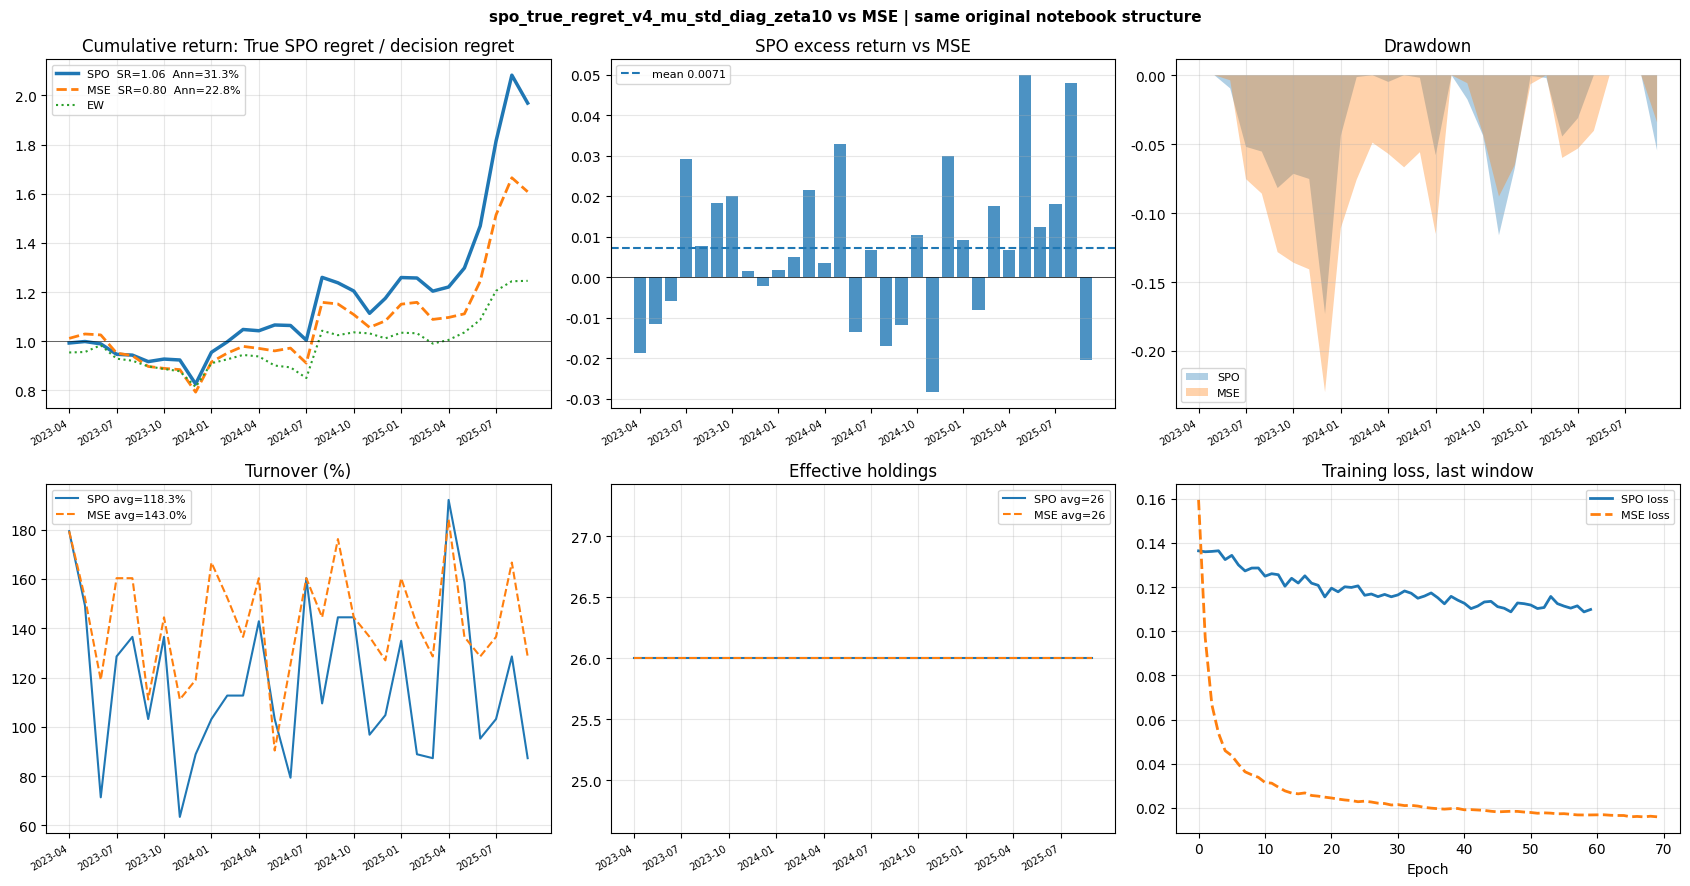

In [11]:
N_TEST = len(r_spo)
x = np.arange(N_TEST)
dlabels = [pd.Timestamp(d).strftime('%Y-%m') for d in res_spo['dates']]
step = max(1, N_TEST // 8)

cum_spo = np.cumprod(1 + r_spo)
cum_mse = np.cumprod(1 + r_mse)
cum_bch = np.cumprod(1 + r_bench)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

ax = axes[0, 0]
ax.plot(cum_spo, lw=2.5, label=f"SPO  SR={m_spo['Sharpe']:.2f}  Ann={m_spo['Ann_Ret']:.1%}")
ax.plot(cum_mse, lw=2.0, ls='--', label=f"MSE  SR={m_mse['Sharpe']:.2f}  Ann={m_mse['Ann_Ret']:.1%}")
ax.plot(cum_bch, lw=1.5, ls=':', label='EW')
ax.axhline(1, color='k', lw=0.4)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title(f'Cumulative return: {SPO_LOSS_LABEL}')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[0, 1]
excess = r_spo - r_mse
ax.bar(x, excess, alpha=0.8)
ax.axhline(excess.mean(), ls='--', lw=1.5, label=f'mean {excess.mean():.4f}')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_title('SPO excess return vs MSE')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

def dd_s(c):
    return (c / np.maximum.accumulate(c)) - 1

ax = axes[0, 2]
ax.fill_between(x, 0, dd_s(cum_spo), alpha=0.35, label='SPO')
ax.fill_between(x, 0, dd_s(cum_mse), alpha=0.35, label='MSE')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Drawdown')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 0]
to_spo = calc_turnover(res_spo['weights'])
to_mse = calc_turnover(res_mse['weights'])
ax.plot(to_spo * 100, lw=1.5, label=f'SPO avg={to_spo.mean():.1%}')
ax.plot(to_mse * 100, lw=1.5, ls='--', label=f'MSE avg={to_mse.mean():.1%}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Turnover (%)')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 1]
eff_spo = [(w > 0.001).sum() for w in res_spo['weights']]
eff_mse = [(w > 0.001).sum() for w in res_mse['weights']]
ax.plot(eff_spo, lw=1.5, label=f'SPO avg={np.mean(eff_spo):.0f}')
ax.plot(eff_mse, lw=1.5, ls='--', label=f'MSE avg={np.mean(eff_mse):.0f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Effective holdings')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 2]
if res_spo['loss_curves']:
    ax.plot(res_spo['loss_curves'][-1], lw=2, label='SPO loss')
if res_mse['loss_curves']:
    ax.plot(res_mse['loss_curves'][-1], lw=2, ls='--', label='MSE loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlabel('Epoch')
ax.set_title('Training loss, last window')

plt.suptitle(f'{SPO_RUN_NAME} vs MSE | same original notebook structure', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
# v4 SPO notebook: no extra trailing experiment cell.
